# 03 · H3 — 셀러 스타일 유형과 판매 성과 (비지도)

**가설.** 셀러는 스타일 시그니처(브랜드 집중도·성별·가격대·컨디션 구성)에 따라 소수의
유형으로 군집되며, 유형에 따라 판매 전환율이 다르다. 저성과 셀러는 같은 유형의 성공
규범에서 벗어나 있어, 일반 조언 대신 "같은 유형의 잘 파는 셀러" 벤치마크가 더 유효하다.

**왜 이 방법인가.** 셀러 '유형'은 사전 정답이 없으므로 비슷한 시그니처끼리 묶는
**K-평균 군집화**로 *발견*한다. 이렇게 묶인 셀러 집단을 **아키타입**(비슷한 시그니처를
공유하는 셀러 유형)이라 부른다. 정답이 없는 군집의 타당성은 두 층위로 본다 —
(i) **군집 존재성**: 변수 간 관계를 없앤 무작위 자료의 응집도와 비교한다(응집도는 각 셀러가
자기 군집에 얼마나 부합하는지를 -1~1로 재는 **실루엣 계수**). 또 초기값을 바꿔도 결과가
일치하는지를 0~1로 재는 **ARI(adjusted Rand index)** 로 안정성을 본다.
(ii) **외적 타당성**: 유형 간 전환율 차이를 정규성 가정 없이 보는 **크러스컬–월리스 검정**과,
그 차이가 실제로 얼마나 큰지를 0~1로 재는 **효과크기 ε²**, 그리고 가격·카테고리 통제
회귀(06)로 확인한다.

**유의수준** α=0.05. 표본이 커 p만으로 판단하지 않고 ε²(효과크기)를 함께 본다.

**구성:** (1) 군집화·k 선택, (2) 아키타입 특성, (2b) 군집 2D 시각화(PCA), (3) 전환율 차이 검정,
(3b) 군집 존재성·효과크기, (4) 유형 내 성공 규범, (5) **키스톤 — 위시↔셀링 취향 예측력**.
산출은 results/h3.json.

In [1]:
import json
from pathlib import Path
import sqlite3

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from scipy.sparse import csr_matrix
from scipy.stats import kruskal
import scikit_posthocs as sp

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
matplotlib.rcParams["font.family"] = "AppleGothic"
matplotlib.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 110
FIG = ROOT / "results" / "figures"
CACHE = ROOT / "data" / "cache"

sel = pd.read_parquet(CACHE / "features_seller.parquet")
lst = pd.read_parquet(CACHE / "features_listing.parquet")

# 시그니처 안정성 위해 매물 5건 이상 셀러만 군집 대상
sel_c = sel[sel["n_listings"] >= 5].copy()
print(f"전체 셀러 {len(sel):,} → 군집대상(매물5+) {len(sel_c):,} ({len(sel_c)/len(sel):.0%})")

전체 셀러 11,095 → 군집대상(매물5+) 9,615 (87%)


## 1. 구조 시그니처로 아키타입 군집 (KMeans, k는 실루엣으로)

군집 수 k를 3~8로 바꿔가며 실루엣 계수가 가장 큰 k를 고른다(분리가 가장 뚜렷한 유형 수).
시그니처가 불안정한 매물 5건 미만 셀러는 군집 대상에서 제외한다(브랜드 분포가 한두 건으로 출렁이기
때문; 전체 셀러의 약 87% 유지).

**시그니처 6피처 선택 근거.** `brand_hhi`·`brand_entropy_norm`(브랜드 집중/다양성), `share_men`(취급 성별),
`share_new`(신상 비중), `log_median_price`(가격대), `avg_n_photos`(등록 습관) — 셀러의 '스타일 정체성'을
이루는 축만 쓰고 **결과변수(sell-through)는 피처에서 제외**해 '유형→성과' 검정이 순환되지 않게 한다.
피처 스케일이 제각각이라 StandardScaler로 표준화한 뒤 군집·PCA한다.

In [2]:
FEATS = ["brand_hhi", "brand_entropy_norm", "share_men", "share_new",
         "log_median_price", "avg_n_photos"]
Xs = sel_c[FEATS].fillna(sel_c[FEATS].median())
Xz = StandardScaler().fit_transform(Xs)

sil = {}
for k in range(3, 9):
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(Xz)
    sil[k] = silhouette_score(Xz, km.labels_, sample_size=5000, random_state=42)
best_k = max(sil, key=sil.get)
print("silhouette by k:", {k: round(v, 3) for k, v in sil.items()})
print("best k =", best_k)

km = KMeans(n_clusters=best_k, n_init=10, random_state=42).fit(Xz)
sel_c["archetype"] = km.labels_

silhouette by k: {3: 0.287, 4: 0.22, 5: 0.239, 6: 0.213, 7: 0.204, 8: 0.199}
best k = 3


## 2. 아키타입 특성 + 대표 브랜드

In [3]:
lst_c = lst.merge(sel_c[["seller_id", "archetype"]], on="seller_id", how="inner")
profile = sel_c.groupby("archetype").agg(
    n_sellers=("seller_id", "size"),
    sell_through=("sell_through", "mean"),
    brand_hhi=("brand_hhi", "mean"),
    share_men=("share_men", "mean"),
    share_new=("share_new", "mean"),
    median_price=("median_price", "median"),
    avg_n_photos=("avg_n_photos", "mean"),
).round(3)
# 대표 브랜드 top3
top_brands = {}
for a, g in lst_c.groupby("archetype"):
    top_brands[int(a)] = g["brand"].value_counts().head(3).index.tolist()
profile["top_brands"] = profile.index.map(lambda a: ", ".join(top_brands.get(a, [])))
print(profile.to_string())

           n_sellers  sell_through  brand_hhi  share_men  share_new  median_price  avg_n_photos                                         top_brands
archetype                                                                                                                                         
0               2377         0.242      0.132      0.206      0.184       70000.0         4.649            Japanese Vintage, Stone Island, Vintage
1               6574         0.215      0.129      0.936      0.182      142750.0         4.671              Stone Island, Polo Ralph Lauren, Nike
2                664         0.149      0.700      0.744      0.318      150000.0         5.201  Japanese Vintage, Stone Island, Polo Ralph Lauren


## 2b. 군집 시각화 — 시그니처 공간의 2D 투영 (PCA)

6차원 시그니처를 PCA로 2D 투영해 아키타입이 실제로 분리되는지 눈으로 본다(라벨은 군집이 사후
부여). 군집 존재성·안정성의 정량 근거는 3b절(무작위참조 실루엣·ARI). 중심(X)에 유형 번호,
범례에 대표 브랜드·전환율을 함께 표기해 "어떤 유형이 잘/덜 파는지"가 공간에서 드러나게 한다.

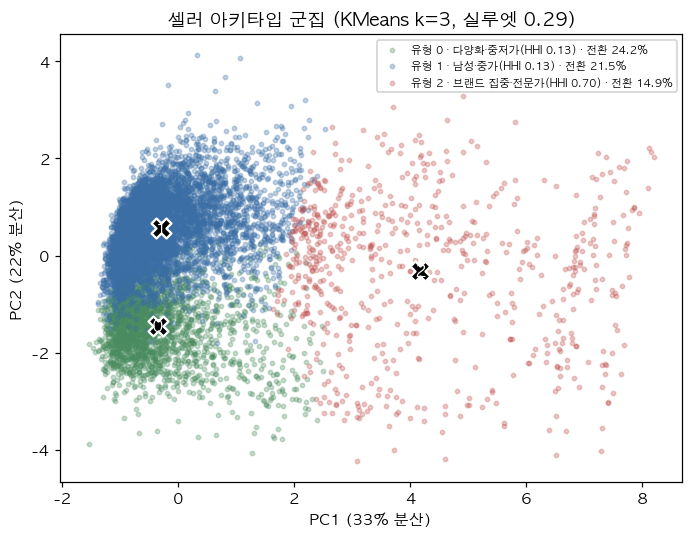

In [4]:
pca = PCA(n_components=2, random_state=42).fit(Xz)
P = pca.transform(Xz)
cen = pca.transform(km.cluster_centers_)
palette = ["#4a8c5f", "#3a6ea5", "#c0504d", "#e6a23c", "#7a5fa0", "#999999"]
fig, ax = plt.subplots(figsize=(6.4, 5))
for a in sorted(sel_c["archetype"].unique()):
    m = sel_c["archetype"].values == a
    st = profile.loc[a, "sell_through"] * 100
    hhi_a = profile.loc[a, "brand_hhi"]; price_a = profile.loc[a, "median_price"]
    # 대표 브랜드(Japanese Vintage 등)는 범용 버킷이라 군집 변별력이 없어, 시그니처(집중도·가격·성별)로 라벨
    desc = ("브랜드 집중·전문가" if hhi_a > 0.4 else
            "다양화·중저가" if price_a < 100000 else "남성·중가")
    lbl = f"유형 {a} · {desc}(HHI {hhi_a:.2f}) · 전환 {st:.1f}%"
    ax.scatter(P[m, 0], P[m, 1], s=8, alpha=0.30, color=palette[a % len(palette)], label=lbl)
ax.scatter(cen[:, 0], cen[:, 1], marker="X", s=170, c="k", edgecolor="w", lw=1.5, zorder=5)
for a in range(best_k):
    ax.annotate(str(a), cen[a], fontsize=11, fontweight="bold", ha="center", va="center",
                color="w", zorder=6)
ax.set(title=f"셀러 아키타입 군집 (KMeans k={best_k}, 실루엣 {sil[best_k]:.2f})",
       xlabel=f"PC1 ({pca.explained_variance_ratio_[0]:.0%} 분산)",
       ylabel=f"PC2 ({pca.explained_variance_ratio_[1]:.0%} 분산)")
ax.legend(fontsize=7, loc="best", framealpha=0.92)
fig.tight_layout(); fig.savefig(FIG / "h3_cluster_scatter.png", bbox_inches="tight"); plt.show()

## 3. 아키타입 × sell-through 차이 검정 (Kruskal-Wallis + Dunn)

선행 연구는 가격만 봤다 — 여기선 전환율 차이가 핵심.

Kruskal-Wallis H=351.1, p=5.86e-77

Dunn posthoc (p, Bonferroni):
     0    1    2
0  1.0  0.0  0.0
1  0.0  1.0  0.0
2  0.0  0.0  1.0


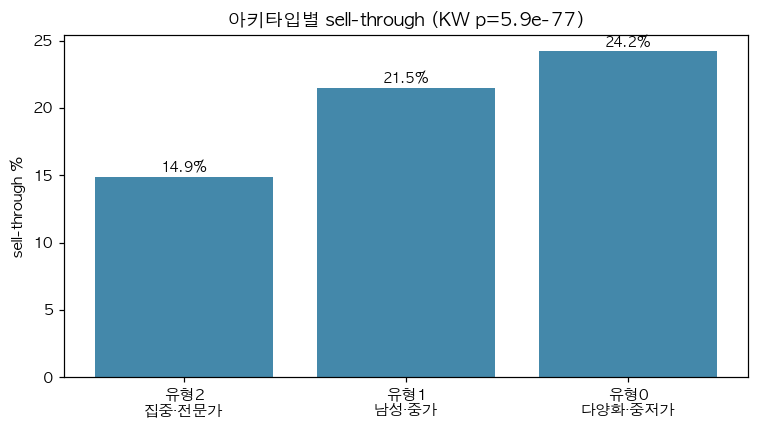

In [5]:
groups = [g["sell_through"].values for _, g in sel_c.groupby("archetype")]
H, p = kruskal(*groups)
print(f"Kruskal-Wallis H={H:.1f}, p={p:.2e}")
dunn = sp.posthoc_dunn(sel_c, val_col="sell_through", group_col="archetype", p_adjust="bonferroni")
print("\nDunn posthoc (p, Bonferroni):")
print(dunn.round(4))

def _arch_desc(a):  # 대표 브랜드(Japanese Vintage 등)는 범용 버킷이라 변별력 없음 → 시그니처로 라벨
    h = profile.loc[a, "brand_hhi"]; pr = profile.loc[a, "median_price"]
    return "집중·전문가" if h > 0.4 else "다양화·중저가" if pr < 100000 else "남성·중가"
fig, ax = plt.subplots(figsize=(7, 4))
order = profile.sort_values("sell_through").index
ax.bar([f"유형{a}\n{_arch_desc(a)}" for a in order], profile.loc[order, "sell_through"]*100, color="#48a")
ax.set(title=f"아키타입별 sell-through (KW p={p:.1e})", ylabel="sell-through %", xlabel="")
for i, a in enumerate(order):
    ax.text(i, profile.loc[a, "sell_through"]*100+0.3, f"{profile.loc[a, 'sell_through']*100:.1f}%",
            ha="center", fontsize=9)
fig.tight_layout(); fig.savefig(FIG / "h3_archetype_sellthrough.png", bbox_inches="tight"); plt.show()

## 3b. 추론 — 군집 존재성(무작위 참조) + KW 효과크기

비지도엔 정답 라벨이 없으므로 검정이 두 층위다. (i) **군집 존재성**: 각 피처 열을
독립적으로 셔플해 결합구조를 파괴한 **무작위 참조** 데이터의 실루엣 분포와 관측 실루엣을
비교 → 귀무 "군집 구조 없음"을 기각(gap-statistic 계열). (ii) **외적 타당성**: 아키타입 간
sell-through 차이의 KW 검정에 **효과크기 ε²**를 덧붙여 유의성과 크기를 함께 본다.

In [6]:
rngs = np.random.RandomState(0); Bc = 50
null_sil = []
for _ in range(Bc):
    Xn = np.column_stack([rngs.permutation(Xz[:, j]) for j in range(Xz.shape[1])])
    lab = KMeans(n_clusters=best_k, n_init=5, random_state=0).fit_predict(Xn)
    null_sil.append(silhouette_score(Xn, lab, sample_size=5000, random_state=0))
null_sil = np.array(null_sil)
obs_sil = sil[best_k]
clust_p = (1 + np.sum(null_sil >= obs_sil)) / (Bc + 1)
eps2 = (H - best_k + 1) / (len(sel_c) - best_k)   # KW 효과크기 ε²
print(f"관측 실루엣 {obs_sil:.3f} vs 무작위참조 {null_sil.mean():.3f}±{null_sil.std():.3f}, p={clust_p:.3f}")
print(f"KW 효과크기 ε² = {eps2:.3f}")
H3_INF = {"obs_silhouette": round(float(obs_sil), 3), "null_silhouette_mean": round(float(null_sil.mean()), 3),
          "clusterability_p": float(clust_p), "kw_epsilon_sq": round(float(eps2), 3)}

관측 실루엣 0.287 vs 무작위참조 0.225±0.017, p=0.020
KW 효과크기 ε² = 0.036


## 4. (보조 점검) 유형 내 상위 vs 하위 셀러의 표현 격차

같은 아키타입 안에서 sell-through 상위 33% vs 하위 33% 셀러가 표현(사진·설명·키워드·상대가격)에서
다른지 본다. 격차가 거의 0이면 '유형 내 성공도 표현 차이에서 오지 않는다'는 H1·H2 결론을 재확인한다.
격차가 미미해 시각화 가치가 낮으므로 그림 없이 수치로만 보고한다.

In [7]:
ctrl_cols = ["n_photos", "desc_len", "kw_measure", "kw_flaw", "kw_material",
             "kw_usage", "relative_price_z"]
seller_repr = lst_c.groupby("seller_id")[ctrl_cols].mean()
sel_b = sel_c.merge(seller_repr, on="seller_id", how="left")

bench = {}
for a, g in sel_b.groupby("archetype"):
    if len(g) < 30:
        continue
    hi = g[g["sell_through"] >= g["sell_through"].quantile(0.67)]
    lo = g[g["sell_through"] <= g["sell_through"].quantile(0.33)]
    bench[int(a)] = {c: {"top": round(hi[c].mean(), 3), "bottom": round(lo[c].mean(), 3),
                         "gap": round(hi[c].mean() - lo[c].mean(), 3)} for c in ctrl_cols}

# 격차를 한눈에 — 아키타입별 (top-bottom) 히트맵
gap_df = pd.DataFrame({a: {c: v[c]["gap"] for c in ctrl_cols} for a, v in bench.items()}).T
print("아키타입별 상위−하위 셀러 표현 격차 (양수=성공셀러가 더 많이 함):")
print(gap_df.round(3).to_string())
print("→ 표현 격차가 대부분 0 부근(desc_len 외 미미) — 유형 내 성공도 표현 차이로 설명되지 않음(H1·H2와 합치).")

아키타입별 상위−하위 셀러 표현 격차 (양수=성공셀러가 더 많이 함):
   n_photos  desc_len  kw_measure  kw_flaw  kw_material  kw_usage  relative_price_z
0    -0.714   -68.393      -0.145   -0.076       -0.127     0.045             0.134
1    -0.543   -28.976      -0.091   -0.083       -0.042    -0.001            -0.025
2    -0.716   -59.229      -0.141   -0.103       -0.063     0.009            -0.056
→ 표현 격차가 대부분 0 부근(desc_len 외 미미) — 유형 내 성공도 표현 차이로 설명되지 않음(H1·H2와 합치).


## 5. 키스톤 — 위시 취향이 셀링 취향을 예측하는가 (브랜드 수준)

신규 셀러는 셀링 이력이 없다. 그럼에도 위시리스트로 취향을 프로파일링해 "비슷한 셀러"에 매핑하려면,
**한 셀러의 위시-브랜드 분포가 그의 셀링-브랜드 분포와 닮아 있어야** 한다. 두 분포를 L2 정규화한
벡터의 코사인 유사도로 재고, owner↔seller 짝을 무작위로 섞은 null과 비교한다(짝지음을 깨면 유사도가
베이스라인으로 떨어진다). 위시·셀링 모두 5건 이상인 셀러만 사용. 한계: 찜 상품의 일부만 우리 매물
universe에 있어 브랜드 매핑됨(아래 coverage). 카테고리(L1)는 종류가 적어 베이스라인이 높으므로(미시연)
변별 신호는 브랜드 수준에서 본다.

wishlist owner 8,830 | 브랜드 매핑된 찜 93,731 (34%)


위시-셀링 브랜드 코사인: 중앙값 0.283, 평균 0.373, >0 87.9%
무작위 null 평균 0.042 → lift 8.9배 (n=5,492)


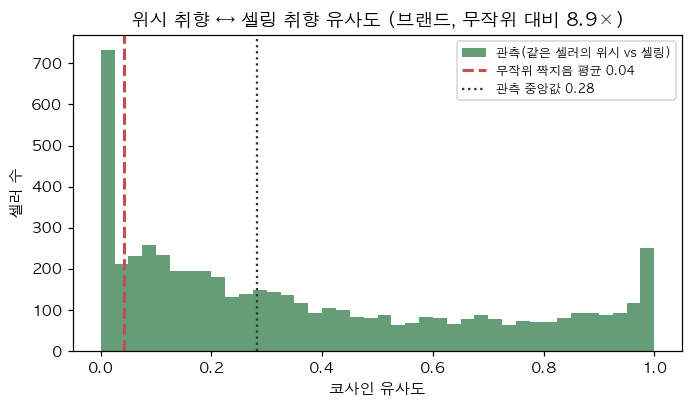

In [8]:
with sqlite3.connect(ROOT / "data" / "fruitsfamily.db") as conn:
    wl = pd.read_sql_query("SELECT owner_seller_id, product_id FROM wishlist", conn)
brand_map = lst.set_index("product_id")["brand"]
wl["brand"] = wl["product_id"].map(brand_map)
wlm = wl.dropna(subset=["brand"])
n_owners = wlm["owner_seller_id"].nunique()
brand_cov = len(wlm) / len(wl)
print(f"wishlist owner {n_owners:,} | 브랜드 매핑된 찜 {len(wlm):,} ({brand_cov:.0%})")

# 셀러별 sell-brand 분포 / wish-brand 분포 → 공통 vocab 위 희소벡터, L2 정규화
sell_cnt = lst.groupby(["seller_id", "brand"]).size().rename("n").reset_index()
wish_cnt = wlm.groupby(["owner_seller_id", "brand"]).size().rename("n").reset_index()
s_tot = lst.groupby("seller_id").size(); w_tot = wlm.groupby("owner_seller_id").size()
both = sorted(set(s_tot[s_tot >= 5].index) & set(w_tot[w_tot >= 5].index))
vocab = sorted(set(sell_cnt["brand"]) | set(wish_cnt["brand"]))
vi = {b: i for i, b in enumerate(vocab)}; bi = {s: i for i, s in enumerate(both)}
sc = sell_cnt[sell_cnt.seller_id.isin(bi)]; wc = wish_cnt[wish_cnt.owner_seller_id.isin(bi)]
S = normalize(csr_matrix((sc.n, (sc.seller_id.map(bi), sc.brand.map(vi))), shape=(len(both), len(vocab))))
W = normalize(csr_matrix((wc.n, (wc.owner_seller_id.map(bi), wc.brand.map(vi))), shape=(len(both), len(vocab))))
cos = np.asarray(S.multiply(W).sum(axis=1)).ravel()         # 같은 셀러의 위시 vs 셀링 코사인
rng = np.random.RandomState(0)
null_means = [np.asarray(S.multiply(W[rng.permutation(W.shape[0])]).sum(axis=1)).ravel().mean()
              for _ in range(20)]                            # 짝지음을 깬 null
null_mean = float(np.mean(null_means)); lift = float(cos.mean() / null_mean)
print(f"위시-셀링 브랜드 코사인: 중앙값 {np.median(cos):.3f}, 평균 {cos.mean():.3f}, >0 {100*(cos>0).mean():.1f}%")
print(f"무작위 null 평균 {null_mean:.3f} → lift {lift:.1f}배 (n={len(both):,})")

fig, ax = plt.subplots(figsize=(6.4, 3.8))
ax.hist(cos, bins=40, color="#4a8c5f", alpha=0.85, label="관측(같은 셀러의 위시 vs 셀링)")
ax.axvline(null_mean, color="#c0504d", ls="--", lw=2, label=f"무작위 짝지음 평균 {null_mean:.2f}")
ax.axvline(np.median(cos), color="#333", ls=":", lw=1.5, label=f"관측 중앙값 {np.median(cos):.2f}")
ax.set(title=f"위시 취향 ↔ 셀링 취향 유사도 (브랜드, 무작위 대비 {lift:.1f}×)",
       xlabel="코사인 유사도", ylabel="셀러 수")
ax.legend(fontsize=8)
fig.tight_layout(); fig.savefig(FIG / "h3_wish_sell_taste.png", bbox_inches="tight"); plt.show()

WST = {"n_sellers_both": int(len(both)), "brand_map_coverage": round(brand_cov, 3),
       "cosine_median": round(float(np.median(cos)), 3), "cosine_mean": round(float(cos.mean()), 3),
       "frac_positive": round(float((cos > 0).mean()), 3),
       "null_mean": round(null_mean, 3), "lift_over_null": round(lift, 2)}

## 5b. 키스톤 강건성 — 벡터공간 설계 민감도 (리뷰어 대응)

위 코사인은 brand_top(상위30+기타)가 아니라 **전체 raw 브랜드 어휘**(line `vocab = ...`)로 계산했다.
롱테일을 '기타' 한 차원으로 묶으면 서로 다른 희소 브랜드가 한 차원에서 거짓 매칭돼 코사인이 부풀 수
있으므로, 어휘 설계를 바꿔가며 lift(관측 평균/무작위 평균)가 어떻게 변하는지 점검한다.

  full         dims= 5439 | 중앙 0.283 | lift 8.9x
  bucket30     dims=   31 | 중앙 0.953 | lift 1.1x
  top30        dims=   30 | 중앙 0.402 | lift 4.7x
  top100       dims=  100 | 중앙 0.339 | lift 6.1x
  idf          dims= 5439 | 중앙 0.222 | lift 13.3x
  svd100       dims=  100 | 중앙 0.363 | lift 6.2x
  drop_top10   dims= 5429 | 중앙 0.251 | lift 13.3x
  drop_generic dims= 5437 | 중앙 0.276 | lift 9.3x
  위시-브랜드 분포 Gini = 0.859 (집중도; 인기편향 점검)
→ '기타' 버킷은 거짓 매칭으로 lift 붕괴, 인기 브랜드 down-weight·head 제거는 강화 → 신호는 중·롱테일 취향에서 옴.


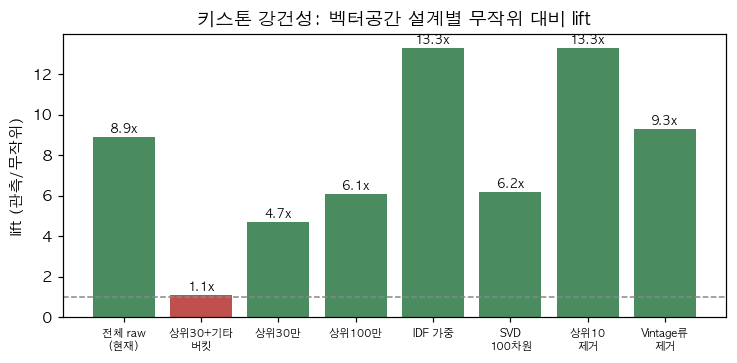

  brand×cat    dims=13599 | 중앙 0.152 | lift 17.6x  (취향 벡터 고도화 → 브랜드 단위는 보수적)
  저이력5~8건 n=498 | 중앙 0.216 | lift 10.8x  (역인과 점검: 유지되면 누적경험 산물 아님)


In [9]:
popb = sc.brand.value_counts()
top10 = list(popb.head(10).index); top30 = list(popb.head(30).index); top100 = list(popb.head(100).index)

def _kw_lift(scheme):
    s, w = sc.copy(), wc.copy()
    if scheme == "drop_top10":
        s = s[~s.brand.isin(top10)]; w = w[~w.brand.isin(top10)]
    if scheme == "drop_generic":
        g = ["Vintage", "Japanese Vintage"]; s = s[~s.brand.isin(g)]; w = w[~w.brand.isin(g)]
    if scheme == "bucket30":      # 리뷰어가 우려한 상위30+기타 버킷
        s = s.assign(b=np.where(s.brand.isin(top30), s.brand, "__OTHER__"))
        w = w.assign(b=np.where(w.brand.isin(top30), w.brand, "__OTHER__"))
    elif scheme in ("top30", "top100"):
        keep = set(top30 if scheme == "top30" else top100)
        s = s[s.brand.isin(keep)].assign(b=lambda d: d.brand); w = w[w.brand.isin(keep)].assign(b=lambda d: d.brand)
    else:
        s = s.assign(b=s.brand); w = w.assign(b=w.brand)
    voc = sorted(set(s.b) | set(w.b)); v2 = {b: i for i, b in enumerate(voc)}
    sa = s.groupby(["seller_id", "b"], as_index=False).n.sum()
    wa = w.groupby(["owner_seller_id", "b"], as_index=False).n.sum()
    Sx = csr_matrix((sa.n, (sa.seller_id.map(bi), sa.b.map(v2))), shape=(len(both), len(voc)), dtype=float)
    Wx = csr_matrix((wa.n, (wa.owner_seller_id.map(bi), wa.b.map(v2))), shape=(len(both), len(voc)), dtype=float)
    if scheme == "svd100":        # 차원축소(희소성·노이즈 점검): TruncatedSVD 후 코사인
        from sklearn.decomposition import TruncatedSVD
        from scipy.sparse import vstack as spvstack
        kc = min(100, min(Sx.shape) - 1)
        svd = TruncatedSVD(n_components=kc, random_state=0).fit(spvstack([Sx, Wx]))
        A = normalize(svd.transform(Sx)); B = normalize(svd.transform(Wx))
        c = (A * B).sum(1)
        nz = (np.abs(A).sum(1) > 0) & (np.abs(B).sum(1) > 0)
        r = np.random.RandomState(0)
        nm = float(np.mean([(A * B[r.permutation(B.shape[0])]).sum(1)[nz].mean() for _ in range(10)]))
        return {"dims": int(kc), "median": round(float(np.median(c[nz])), 3),
                "lift": round(float(c[nz].mean() / nm), 1)}
    if scheme == "idf":           # 인기 브랜드 down-weight (롱테일 보존)
        dfb = np.asarray((Sx > 0).sum(0)).ravel() + np.asarray((Wx > 0).sum(0)).ravel()
        idfw = np.log((2 * len(both) + 1) / (dfb + 1)) + 1
        Sx = Sx.multiply(idfw).tocsr(); Wx = Wx.multiply(idfw).tocsr()
    Sx = normalize(Sx); Wx = normalize(Wx)
    c = np.asarray(Sx.multiply(Wx).sum(1)).ravel()
    nz = (np.asarray((Sx != 0).sum(1)).ravel() > 0) & (np.asarray((Wx != 0).sum(1)).ravel() > 0)
    r = np.random.RandomState(0)
    nm = float(np.mean([np.asarray(Sx.multiply(Wx[r.permutation(Wx.shape[0])]).sum(1)).ravel()[nz].mean()
                        for _ in range(10)]))
    return {"dims": int(len(voc)), "median": round(float(np.median(c[nz])), 3),
            "lift": round(float(c[nz].mean() / nm), 1)}

ROBUST = {s: _kw_lift(s) for s in ["full", "bucket30", "top30", "top100", "idf", "svd100", "drop_top10", "drop_generic"]}
for k, v in ROBUST.items():
    print(f"  {k:12s} dims={v['dims']:5d} | 중앙 {v['median']:.3f} | lift {v['lift']}x")

# 인기도 편향 점검용: 위시-브랜드 빈도분포의 집중도(Gini). 집중돼 있어도 head(top10) 제거 시 lift가
# 오히려 오르므로(위 drop_top10), 8.9배가 인기 브랜드 공통 찜의 허수가 아님을 함께 보인다.
def _gini(v):
    v = np.sort(np.asarray(v, dtype=float)); n = len(v)
    return float((2 * np.arange(1, n + 1) - n - 1) @ v / (n * v.sum())) if v.sum() else 0.0
wish_gini = _gini(wc.groupby("brand")["n"].sum().values)
print(f"  위시-브랜드 분포 Gini = {wish_gini:.3f} (집중도; 인기편향 점검)")
print("→ '기타' 버킷은 거짓 매칭으로 lift 붕괴, 인기 브랜드 down-weight·head 제거는 강화 → 신호는 중·롱테일 취향에서 옴.")

fig, ax = plt.subplots(figsize=(6.8, 3.4))
labs = {"full": "전체 raw\n(현재)", "bucket30": "상위30+기타\n버킷", "top30": "상위30만",
        "top100": "상위100만", "idf": "IDF 가중", "svd100": "SVD\n100차원", "drop_top10": "상위10\n제거", "drop_generic": "Vintage류\n제거"}
ks = list(ROBUST); vals = [ROBUST[k]["lift"] for k in ks]
ax.bar([labs[k] for k in ks], vals, color=["#c0504d" if k == "bucket30" else "#4a8c5f" for k in ks])
ax.axhline(1.0, color="#888", ls="--", lw=1)
for i, vv in enumerate(vals):
    ax.text(i, vv + 0.2, f"{vv}x", ha="center", fontsize=8)
ax.set(title="키스톤 강건성: 벡터공간 설계별 무작위 대비 lift", ylabel="lift (관측/무작위)")
ax.tick_params(axis="x", labelsize=7)
fig.tight_layout(); fig.savefig(FIG / "h3_keystone_robust.png", bbox_inches="tight"); plt.show()

# 취향 벡터 고도화(리뷰어 제안): brand×category_l2 결합 토큰 — 같은 Nike라도 상의/신발 등으로 분리
cof = lst.set_index("product_id")["category_l2"]
slc = lst.dropna(subset=["brand", "category_l2"]).copy()
slc["tok"] = slc["brand"].astype(str) + "|" + slc["category_l2"].astype(str)
wlc = wlm.assign(cat=wlm["product_id"].map(cof)).dropna(subset=["cat"])
wlc = wlc.assign(tok=wlc["brand"].astype(str) + "|" + wlc["cat"].astype(str))
sbc = slc[slc.seller_id.isin(bi)].groupby(["seller_id", "tok"], as_index=False).size().rename(columns={"size": "n"})
wbc = wlc[wlc.owner_seller_id.isin(bi)].groupby(["owner_seller_id", "tok"], as_index=False).size().rename(columns={"size": "n"})
vocbc = sorted(set(sbc.tok) | set(wbc.tok)); vbc = {t: i for i, t in enumerate(vocbc)}
Sbc = normalize(csr_matrix((sbc.n, (sbc.seller_id.map(bi), sbc.tok.map(vbc))), shape=(len(both), len(vocbc))))
Wbc = normalize(csr_matrix((wbc.n, (wbc.owner_seller_id.map(bi), wbc.tok.map(vbc))), shape=(len(both), len(vocbc))))
cbc = np.asarray(Sbc.multiply(Wbc).sum(1)).ravel()
nzbc = (np.asarray((Sbc != 0).sum(1)).ravel() > 0) & (np.asarray((Wbc != 0).sum(1)).ravel() > 0)
rbc = np.random.RandomState(0)
nmbc = float(np.mean([np.asarray(Sbc.multiply(Wbc[rbc.permutation(Wbc.shape[0])]).sum(1)).ravel()[nzbc].mean()
                      for _ in range(10)]))
ROBUST["brand_cat"] = {"dims": int(len(vocbc)), "median": round(float(np.median(cbc[nzbc])), 3),
                       "lift": round(float(cbc[nzbc].mean() / nmbc), 1)}
print(f"  brand×cat    dims={len(vocbc):5d} | 중앙 {ROBUST['brand_cat']['median']:.3f} | lift {ROBUST['brand_cat']['lift']}x  (취향 벡터 고도화 → 브랜드 단위는 보수적)")

# 역인과 점검(리뷰어): 위시가 셀링을 후행한 결과라면 매물 많은 고이력 셀러에서 정렬이 강하고
# 저이력(신규 근사) 셀러에서 약해야 한다. 저이력 5~8건 셀러만 떼어 lift가 유지되는지 본다.
nlist = sel.set_index("seller_id")["n_listings"]
low = [s for s in both if 5 <= nlist.get(s, 0) <= 8]
lb = {s: i for i, s in enumerate(low)}
scl = sc[sc.seller_id.isin(lb)]; wcl = wc[wc.owner_seller_id.isin(lb)]
Sl = normalize(csr_matrix((scl.n, (scl.seller_id.map(lb), scl.brand.map(vi))), shape=(len(low), len(vocab))))
Wl = normalize(csr_matrix((wcl.n, (wcl.owner_seller_id.map(lb), wcl.brand.map(vi))), shape=(len(low), len(vocab))))
cl = np.asarray(Sl.multiply(Wl).sum(1)).ravel()
rl = np.random.RandomState(0)
nml = float(np.mean([np.asarray(Sl.multiply(Wl[rl.permutation(Wl.shape[0])]).sum(1)).ravel().mean() for _ in range(10)]))
ROBUST["low_listing_5_8"] = {"n": int(len(low)), "median": round(float(np.median(cl)), 3),
                             "lift": round(float(cl.mean() / nml), 1)}
print(f"  저이력5~8건 n={len(low)} | 중앙 {ROBUST['low_listing_5_8']['median']} | lift {ROBUST['low_listing_5_8']['lift']}x  (역인과 점검: 유지되면 누적경험 산물 아님)")

## 6. 저장 — seller_clusters.parquet 재생성 + results/h3.json

In [10]:
sel_c[["seller_id", "archetype"]].to_parquet(CACHE / "seller_clusters.parquet", index=False)

h3 = {
    "n_sellers_clustered": int(len(sel_c)),
    "coverage_of_all_sellers": round(len(sel_c)/len(sel), 3),
    "best_k": int(best_k),
    "silhouette": {int(k): round(v, 3) for k, v in sil.items()},
    "archetype_profile": json.loads(profile.reset_index().to_json(orient="records", force_ascii=False)),
    "kruskal": {"H": round(float(H), 2), "p": float(p)},
    "inference": H3_INF,
    "sellthrough_range_across_archetypes": [round(float(profile["sell_through"].min()), 3),
                                            round(float(profile["sell_through"].max()), 3)],
    "benchmark_gap": bench,
    "wish_sell_taste": WST,
    "wish_sell_taste_robustness": ROBUST,
    "wish_brand_gini": round(float(wish_gini), 3),
}
(ROOT / "results" / "h3.json").write_text(
    json.dumps(h3, ensure_ascii=False, indent=2), encoding="utf-8")
print("saved. archetypes:", best_k, "| sell-through range:",
      h3["sellthrough_range_across_archetypes"])

saved. archetypes: 3 | sell-through range: [0.149, 0.242]
